In [2]:
from matplotlib.patches import Patch
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np
from brokenaxes import brokenaxes
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

In [16]:
def combine_dfs(dfs: list[pd.DataFrame]) -> pd.DataFrame:
    r2_df = pd.concat([df[["name", "r2_test"]] for df in dfs])

    r2_df["group"] = r2_df["name"].str.extract(r"^(w_atom|w_bond|baseline|full|rdkit|mol)")
    return r2_df

In [17]:
df_w_charge = pd.read_json(r"..\data\chemprop_results\1_chemprop_no_added_w_charge_rerun_results.json")
df_w_charge["name"] = "baseline"
df_w_charge.head()

,fold_id,size,r2_test,mse_test,message_hidden_dim,depth,ffn_hidden_dim,ffn_n_layers,name
0,0,1,0.853570,0.145305,329,5,392,3,baseline
1,10,1,0.864841,0.137030,338,5,362,3,baseline
2,11,1,0.859010,0.140832,157,5,412,3,baseline
3,12,1,0.847881,0.156346,114,5,189,3,baseline
4,13,1,0.832680,0.163367,298,5,432,2,baseline


In [18]:
df_w_atom = pd.read_json(r"..\data\chemprop_results\1_chemprop_atom_feat_rerun_results.json")
df_w_atom["name"] = "w_atom"
df_w_atom.head()

,fold_id,size,r2_test,mse_test,message_hidden_dim,depth,ffn_hidden_dim,ffn_n_layers,name
0,0,1,0.853236,0.145636,417,1,394,4,w_atom
1,10,1,0.854418,0.147598,148,1,223,5,w_atom
2,11,1,0.858636,0.141205,147,1,228,4,w_atom
3,12,1,0.856169,0.147827,340,3,220,4,w_atom
4,13,1,0.850406,0.146060,346,3,140,3,w_atom


In [19]:
df_w_bond = pd.read_json(r"..\data\chemprop_results\1_chemprop_atom_bond_rerun_results.json")
df_w_bond["name"] = "w_bond"
df_w_bond.head()

,fold_id,size,r2_test,mse_test,message_hidden_dim,depth,ffn_hidden_dim,ffn_n_layers,name
0,0,1,0.851391,0.147467,162,2,159,3,w_bond
1,10,1,0.860615,0.141315,216,1,393,3,w_bond
2,11,1,0.860444,0.139400,175,1,180,4,w_bond
3,12,1,0.856573,0.147413,102,1,144,4,w_bond
4,13,1,0.867549,0.129322,156,1,246,4,w_bond


In [20]:
df_full = pd.read_json(r"..\data\chemprop_results\1_chemprop_full_feat_rerun_results.json")
df_full["name"] = "full"
df_full.head()

,fold_id,size,r2_test,mse_test,message_hidden_dim,depth,ffn_hidden_dim,ffn_n_layers,name
0,0,1,0.860169,0.138757,100,2,236,5,full
1,10,1,0.864261,0.137619,223,1,286,5,full
2,11,1,0.867435,0.132417,117,1,237,3,full
3,12,1,0.858450,0.145483,127,2,334,3,full
4,13,1,0.864684,0.132119,184,2,299,4,full


In [21]:
df_mol = pd.read_json(r"..\data\chemprop_results\1_chemprop_mol_feat_rerun_results.json")
df_mol["name"] = "mol"
df_mol.head()

,fold_id,size,r2_test,mse_test,message_hidden_dim,depth,ffn_hidden_dim,ffn_n_layers,name
0,0,1,0.878014,0.121049,374,4,185,4,mol
1,10,1,0.848851,0.153242,251,4,134,3,mol
2,11,1,0.873342,0.126516,277,3,253,4,mol
3,12,1,0.875263,0.128203,330,3,237,5,mol
4,13,1,0.881868,0.115341,408,5,204,4,mol


In [22]:
df_rdkit = pd.read_json(r"..\data\chemprop_results\1_chemprop_w_rdkit_rerun_results.json")
df_rdkit["name"] = "rdkit"
df_rdkit.head()

,fold_id,size,r2_test,mse_test,message_hidden_dim,depth,ffn_hidden_dim,ffn_n_layers,name
0,0,1,0.873008,0.126016,316,5,357,3,rdkit
1,10,1,0.877773,0.123920,395,5,429,2,rdkit
2,11,1,0.876574,0.123288,306,4,496,2,rdkit
3,12,1,0.871869,0.131691,153,4,206,5,rdkit
4,13,1,0.850883,0.145594,365,5,488,3,rdkit


In [23]:
r2_df = combine_dfs([df_w_atom, df_w_charge, df_w_bond, df_full, df_rdkit, df_mol])
r2_df.head()
r2_df.group.unique()

<StringArray>
['w_atom', 'baseline', 'w_bond', 'full', 'rdkit', 'mol']
Length: 6, dtype: str

In [24]:
summary = r2_df.groupby("group")["r2_test"].agg(["mean", "std"]).reset_index()

display(summary)

,group,mean,std
0,baseline,0.853567,0.013201
1,full,0.858962,0.008402
2,mol,0.872205,0.009966
3,rdkit,0.871629,0.010009
4,w_atom,0.854503,0.004753
5,w_bond,0.853407,0.008251


In [25]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.lines as mlines

# variants = ["w_atom", "w_bond", "full", "baseline"]
# colors   = {"baseline": "grey", "w_atom": "tab:blue", "w_bond": "tab:red", "full": "tab:orange"}
# markers  = {"baseline": "s",    "w_atom": "o", "w_bond": "o", "full": "o"}
# labels   = {"baseline": "Chemprop Baseline", "w_atom": "W atom", "w_bond": "W bond", "full": "Full"}

# fig, ax = plt.subplots(figsize=(8,3.5))

# y = 0  # single row
# jitter = 0.08

# means = {v: summary.loc[summary["group"] == v, "mean"].values[0] for v in variants}

# # Connecting line (dumbbell bar)
# ax.plot([means["baseline"], means["w_atom"]], [y, y],
#         color="lightgrey", linewidth=2, zorder=1)

# # Delta label
# delta = means["w_atom"] - means["baseline"]
# mid_x = (means["baseline"] + means["w_atom"]) / 2
# ax.text(mid_x, y + 0.02, r"$\Delta$R$^2$" + f"={delta:+.3f}",
#         ha="center", va="bottom", fontsize=14)

# for variant in variants:
#     m = means[variant]
#     s = summary.loc[summary["group"] == variant, "std"].values[0]

#     subset = r2_df[r2_df["name"] == variant]["r2_test"].values
#     jittered_y = y + np.random.uniform(-jitter, jitter, size=len(subset))

#     ax.scatter(subset, jittered_y,
#                color=colors[variant], marker=markers[variant],
#                alpha=0.3, s=20, zorder=2)

#     ax.scatter(m, y,
#                color=colors[variant], marker=markers[variant],
#                s=120, zorder=4, edgecolors="white", linewidths=1.2)

#     ax.errorbar(m, y, xerr=s,
#                 fmt="none", color=colors[variant],
#                 capsize=5, capthick=1.5, linewidth=1.5, zorder=3)

# # No y-axis ticks needed for a single row
# ax.set_yticks([])
# ax.tick_params(axis="x", labelsize=16)

# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.spines["left"].set_visible(False)
# ax.spines["bottom"].set_linewidth(1.2)
# ax.grid(False)

# # Legend
# handles = [
#     mlines.Line2D([], [], color=colors[v], marker=markers[v],
#                   linestyle="None", markersize=9, label=labels[v])
#     for v in variants
# ]
# ax.legend(handles=handles, frameon=False, loc="upper left", fontsize=14)

# ax.set_xlabel(r"Test R$^2$", fontsize=18)

# plt.tight_layout()

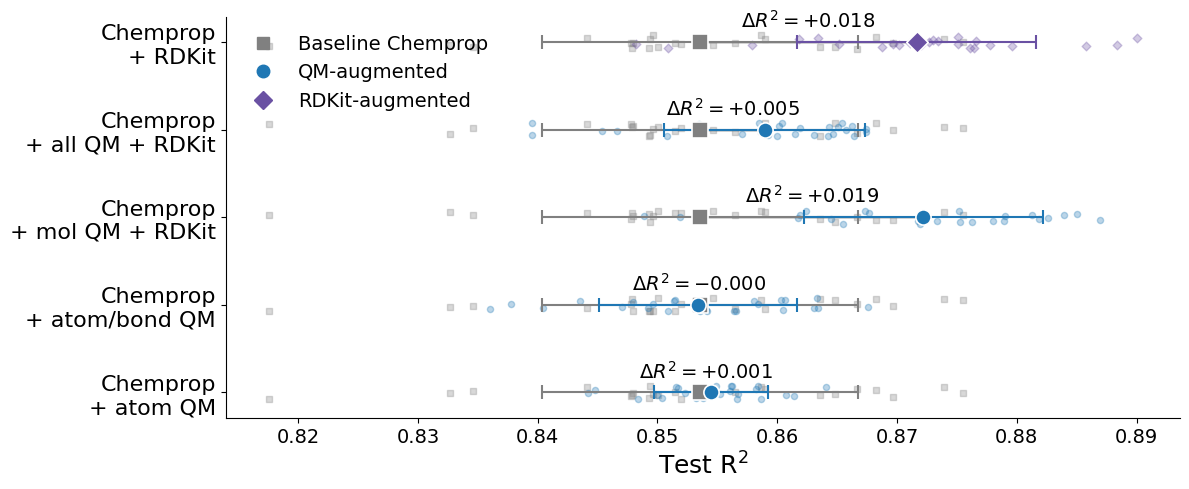

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

comparisons = ["w_atom", "w_bond", "mol", "full", "rdkit"]
variants = ["baseline", *comparisons]

# colors = {
#     "baseline": "grey",
#     "w_atom": "tab:blue",
#     "w_bond": "tab:blue",
#     "full": "tab:blue",
#     "rdkit": "tab:blue",
# }

colors = {
    "baseline": "grey",
    "w_atom": "tab:blue",
    "w_bond": "tab:blue",
    "full": "tab:blue",
    "mol": "tab:blue",
    "rdkit": "#6a51a3",
}

# markers = {
#     "baseline": "s",
#     "w_atom": "o",
#     "w_bond": "o",
#     "full": "o",
#     "rdkit": "o",
# }

markers = {
    "baseline": "s",
    "w_atom": "o",
    "w_bond": "o",
    "full": "o",
    "mol": "o",
    "rdkit": "D",
}

labels = {
    "baseline": "Baseline Chemprop",
    "w_atom": "Chemprop\n+ atom QM",
    "w_bond": "Chemprop\n+ atom/bond QM",
    "full": "Chemprop\n+ all QM + RDKit",
    "mol": "Chemprop\n+ mol QM + RDKit",
    "rdkit": "Chemprop\n+ RDKit",
}

fig, ax = plt.subplots(figsize=(12, 5))

jitter = 0.08

means = {
    v: summary.loc[summary["group"] == v, "mean"].iloc[0]
    for v in variants
}

stds = {
    v: summary.loc[summary["group"] == v, "std"].iloc[0]
    for v in variants
}

for y, variant in enumerate(comparisons):

    baseline_mean = means["baseline"]
    variant_mean = means[variant]

    # connecting line
    ax.plot(
        [baseline_mean, variant_mean],
        [y, y],
        color="lightgrey",
        linewidth=2,
        zorder=1,
    )

    # delta annotation
    delta = variant_mean - baseline_mean
    mid_x = (baseline_mean + variant_mean) / 2

    ax.text(
        mid_x,
        y + 0.12,
        rf"$\Delta R^2={delta:+.3f}$",
        ha="center",
        va="bottom",
        fontsize=14,
    )

    for current in ["baseline", variant]:

        subset = r2_df.loc[
            r2_df["name"] == current,
            "r2_test"
        ].values

        jittered_y = y + np.random.uniform(
            -jitter,
            jitter,
            size=len(subset)
        )

        ax.scatter(
            subset,
            jittered_y,
            color=colors[current],
            marker=markers[current],
            alpha=0.3,
            s=20,
            zorder=2,
        )

        ax.scatter(
            means[current],
            y,
            color=colors[current],
            marker=markers[current],
            s=120,
            zorder=4,
            edgecolors="white",
            linewidths=1.2,
        )

        ax.errorbar(
            means[current],
            y,
            xerr=stds[current],
            fmt="none",
            color=colors[current],
            capsize=5,
            capthick=1.5,
            linewidth=1.5,
            zorder=3,
        )

ax.set_yticks(range(len(comparisons)))
ax.set_yticklabels(
    [labels[v] for v in comparisons],
    fontsize=16,
)

ax.tick_params(axis="x", labelsize=14)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

handles = [
    mlines.Line2D([], [], color="grey", marker="s",
                  linestyle="None", markersize=9,
                  label="Baseline Chemprop"),

    mlines.Line2D([], [], color="tab:blue", marker="o",
                  linestyle="None", markersize=9,
                  label="QM-augmented"),

    mlines.Line2D([], [], color="#6a51a3", marker="D",
                  linestyle="None", markersize=9,
                  label="RDKit-augmented"),
]

ax.legend(
    handles=handles,
    frameon=False,
    loc="upper left",
    fontsize=14
)

ax.set_xlabel(r"Test R$^2$", fontsize=18)

plt.tight_layout()
# plt.savefig("chemprop_scores.pdf", format="pdf")
plt.show()

In [38]:
from ml_enhance import StatisticalComparison

from math import floor

n_tot = 8759 # 8763 before rerun
n_train = floor(n_tot * (4/5))
n_test = n_tot - n_train

In [39]:
atomcomp = StatisticalComparison(df_w_charge["r2_test"].to_numpy(), df_w_atom["r2_test"].to_numpy())
atomcomp.nadeau_bengio_corrected_t_test(n_train, n_test)

{'t_stat': np.float64(-0.3563996514339036),
 'p_value': np.float64(0.7246554420485389),
 'mean_diff': np.float64(-0.0009362793000000025)}

In [40]:
bondcomp = StatisticalComparison(df_w_charge["r2_test"].to_numpy(), df_w_bond["r2_test"].to_numpy())
bondcomp.nadeau_bengio_corrected_t_test(n_train, n_test)

{'t_stat': np.float64(0.054271227296742545),
 'p_value': np.float64(0.9571683221245042),
 'mean_diff': np.float64(0.00015986204799999903)}

In [41]:
fullcomp = StatisticalComparison(df_w_charge["r2_test"].to_numpy(), df_full["r2_test"].to_numpy())
fullcomp.nadeau_bengio_corrected_t_test(n_train, n_test)

{'t_stat': np.float64(-1.947122402342224),
 'p_value': np.float64(0.06331347699950829),
 'mean_diff': np.float64(-0.0053951072720000055)}

In [42]:
fullcomp = StatisticalComparison(df_w_charge["r2_test"].to_numpy(), df_mol["r2_test"].to_numpy())
fullcomp.nadeau_bengio_corrected_t_test(n_train, n_test)

{'t_stat': np.float64(-5.648154506674074),
 'p_value': np.float64(8.14206612309576e-06),
 'mean_diff': np.float64(-0.018638248439999984)}

In [43]:
rdkitcomp = StatisticalComparison(df_w_charge["r2_test"].to_numpy(), df_rdkit["r2_test"].to_numpy())
rdkitcomp.nadeau_bengio_corrected_t_test(n_train, n_test)

{'t_stat': np.float64(-8.078996849896201),
 'p_value': np.float64(2.6510056816420047e-08),
 'mean_diff': np.float64(-0.018062605852000008)}